### Initial Data Inspection

In [ ]:
# Use .info() to check data types and identify null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Use .describe() to see the statistical distribution of numerical data
display(df.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Phase 2: Data Cleaning (Handling Missing Values)

In [ ]:
# Numerical Data Imputation: Fill missing 'Age' values with the Median
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"Filled missing 'Age' values with median: {median_age}.")

Filled missing 'Age' values with median: 28.0.


In [ ]:
# Categorical Data Imputation: Fill missing 'Embarked' values with the Mode
mode_embarked = df['Embarked'].mode()[0] # .mode() returns a Series, so take the first element
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"Filled missing 'Embarked' values with mode: {mode_embarked}.")

Filled missing 'Embarked' values with mode: S.


In [ ]:
# Verify: Check for any remaining missing values
print('\nMissing values after cleaning:')
display(df.isnull().sum())


Missing values after cleaning:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Display the first few rows of the cleaned DataFrame
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
# Numerical Data Imputation: Fill missing 'Age' values with the Median
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"Filled missing 'Age' values with median: {median_age}.")

Filled missing 'Age' values with median: 28.0.


In [ ]:
# Categorical Data Imputation: Fill missing 'Embarked' values with the Mode
mode_embarked = df['Embarked'].mode()[0] # .mode() returns a Series, so take the first element
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"Filled missing 'Embarked' values with mode: {mode_embarked}.")

Filled missing 'Embarked' values with mode: S.


In [ ]:
# Verify: Check for any remaining missing values
print('\nMissing values after cleaning:')
display(df.isnull().sum())


Missing values after cleaning:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Display the first few rows of the cleaned DataFrame
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Phase 3: Feature Engineering (Encoding and Scaling)

### Phase 4: Outlier Detection and Removal

#### Visualization: Boxplots to Identify Outliers
We will use boxplots to visualize the distribution of our numerical features and identify potential outliers that fall outside the whiskers.

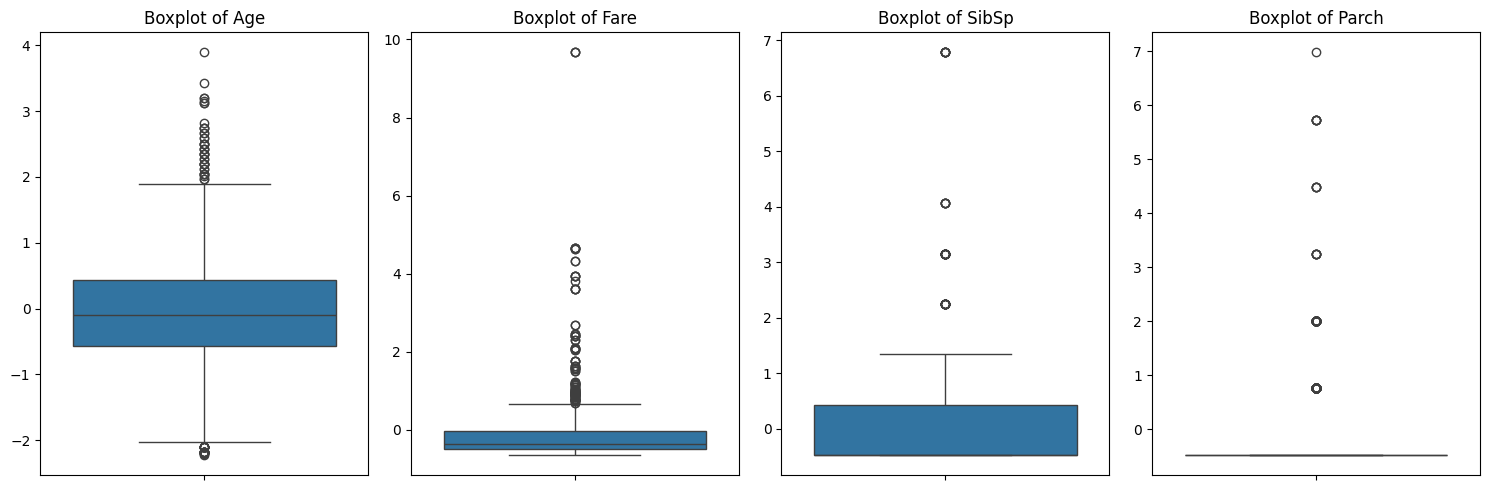

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for boxplots (these are already scaled from Phase 3)
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Create boxplots for the numerical features
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Hide y-axis label to avoid clutter
plt.tight_layout()
plt.show()

#### Mathematical Removal: IQR Method
We will use the Interquartile Range (IQR) method to define upper and lower bounds for each numerical feature and filter out data points that fall outside these limits.

In [ ]:
# Store original DataFrame shape for comparison
initial_shape = df.shape
print(f"Initial DataFrame shape: {initial_shape}")

# Apply IQR method to numerical columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    print(f"Outliers removed from '{col}'. New shape: {df.shape}")

final_shape = df.shape
print(f"Final DataFrame shape after outlier removal: {final_shape}")
print(f"Number of rows removed: {initial_shape[0] - final_shape[0]}")

# Display the first few rows of the DataFrame after outlier removal
display(df.head())

Initial DataFrame shape: (891, 11)
Outliers removed from 'Age'. New shape: (825, 11)
Outliers removed from 'Fare'. New shape: (718, 11)
Outliers removed from 'SibSp'. New shape: (689, 11)
Outliers removed from 'Parch'. New shape: (577, 11)
Final DataFrame shape after outlier removal: (577, 11)
Number of rows removed: 314


,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",-0.565736,0.432793,-0.473674,A/5 21171,-0.502445,True,False,True
2,1,3,"Heikkinen, Miss. Laina",-0.258337,-0.474545,-0.473674,STON/O2. 3101282,-0.488854,False,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,0.432793,-0.473674,113803,0.420730,False,False,True
4,0,3,"Allen, Mr. William Henry",0.433312,-0.474545,-0.473674,373450,-0.486337,True,False,True
5,0,3,"Moran, Mr. James",-0.104637,-0.474545,-0.473674,330877,-0.478116,True,True,False


#### Categorical Encoding
We will apply One-Hot Encoding to the nominal categorical columns 'Sex' and 'Embarked'.

*   **'Sex'**: Has two categories ('male', 'female'). One-hot encoding will create new binary columns.
*   **'Embarked'**: Has three categories ('S', 'C', 'Q'). One-hot encoding will create new binary columns.

Columns 'Name', 'Ticket', and 'PassengerId' are generally not useful for direct encoding in a predictive model due to their high cardinality or role as identifiers. 'PassengerId' is typically dropped, and 'Name' and 'Ticket' would require more complex feature extraction if deemed relevant (e.g., extracting titles from 'Name', or patterns from 'Ticket'), which is beyond basic encoding for this phase.

In [ ]:
# Apply One-Hot Encoding to 'Sex' and 'Embarked'
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Display the first few rows with encoded features
display(df.head())

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


#### Feature Scaling
We will apply Standardization to numerical features that are continuous or have a wide range, as many ML algorithms perform better when features are on a similar scale.

*   **Standardization** (Z-score normalization) transforms data to have a mean of 0 and a standard deviation of 1. This is suitable for algorithms that assume a Gaussian distribution or are sensitive to feature scales (e.g., SVMs, Logistic Regression, Neural Networks).

We will scale 'Age', 'Fare', 'SibSp', and 'Parch'. 'Survived' is the target variable, 'Pclass' is already an ordinal numerical category (1, 2, 3) and can be left as is, and 'PassengerId' is an identifier that will be dropped.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop 'PassengerId' as it's an identifier and not a feature for the model
df = df.drop('PassengerId', axis=1)

# Identify numerical columns to scale (excluding 'Survived' and encoded categorical features)
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization to the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical features scaled using Standardization.")
# Display the first few rows of the DataFrame with scaled features
display(df.head())

Numerical features scaled using Standardization.


,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",-0.565736,0.432793,-0.473674,A/5 21171,-0.502445,True,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,0.432793,-0.473674,PC 17599,0.786845,False,False,False
2,1,3,"Heikkinen, Miss. Laina",-0.258337,-0.474545,-0.473674,STON/O2. 3101282,-0.488854,False,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,0.432793,-0.473674,113803,0.420730,False,False,True
4,0,3,"Allen, Mr. William Henry",0.433312,-0.474545,-0.473674,373450,-0.486337,True,False,True


In [ ]:
# Identify Nulls: Use .isnull().sum() to count missing values in each column
print('Missing values before cleaning:')
display(df.isnull().sum())

Missing values before cleaning:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Based on the counts:
*   **Cabin** has 687 missing values, which is approximately 77% of the data. As per the instructions, if a column has more than 70% missing data, it's better to drop it.
*   **Age** has 177 missing values (around 20%). This is numerical, and we'll use the median for imputation to be robust to potential outliers.
*   **Embarked** has 2 missing values (less than 1%). This is categorical, and we'll use the mode for imputation.

In [ ]:
# Dropping: Drop 'Cabin' column due to more than 70% missing data
df = df.drop('Cabin', axis=1)
print("Dropped 'Cabin' column.")

Dropped 'Cabin' column.


In [ ]:
# Numerical Data Imputation: Fill missing 'Age' values with the Median
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"Filled missing 'Age' values with median: {median_age}.")

Filled missing 'Age' values with median: 28.0.


In [ ]:
# Categorical Data Imputation: Fill missing 'Embarked' values with the Mode
mode_embarked = df['Embarked'].mode()[0] # .mode() returns a Series, so take the first element
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"Filled missing 'Embarked' values with mode: {mode_embarked}.")

Filled missing 'Embarked' values with mode: S.


In [ ]:
# Verify: Check for any remaining missing values
print('\nMissing values after cleaning:')
display(df.isnull().sum())


Missing values after cleaning:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Display the first few rows of the cleaned DataFrame
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
